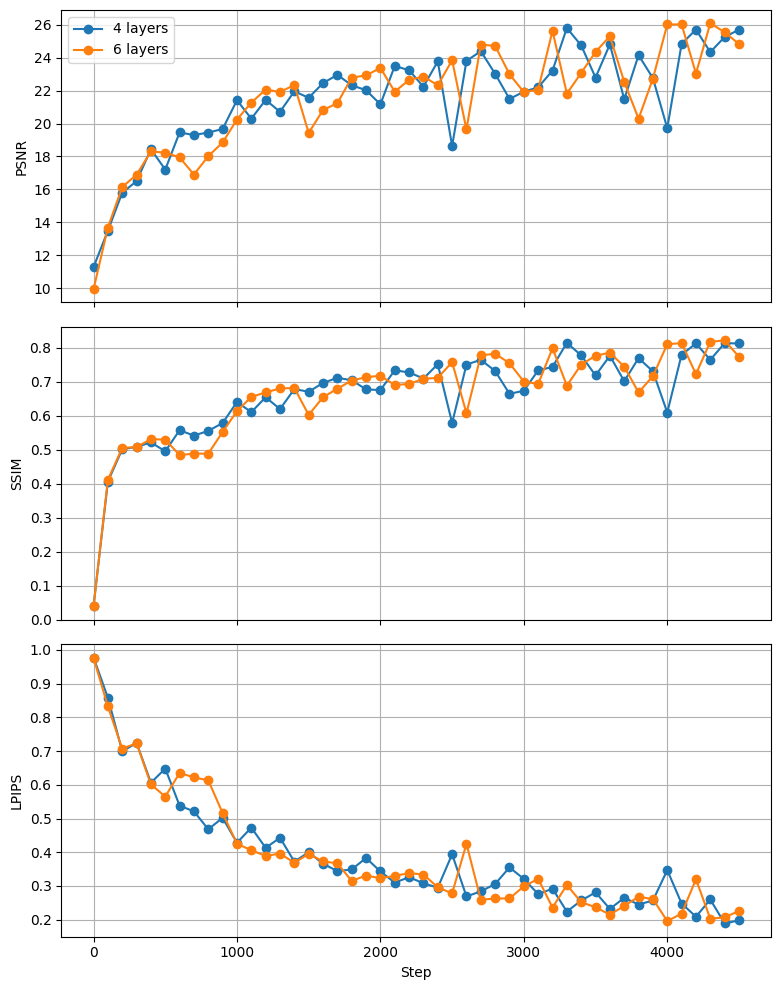

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Define the raw log texts
log_4 = """[2025-11-07 09:13:18] Step: 0, Loss: nan, PSNR: 11.275, SSIM: 0.040, LPIPS: 0.977, LR: 4.000e-06 [2025-11-07 09:15:54] Step: 100, Loss: nan, PSNR: 13.488, SSIM: 0.406, LPIPS: 0.858, LR: 1.984e-05 [2025-11-07 09:18:20] Step: 200, Loss: nan, PSNR: 15.794, SSIM: 0.501, LPIPS: 0.699, LR: 3.568e-05 [2025-11-07 09:20:46] Step: 300, Loss: nan, PSNR: 16.498, SSIM: 0.508, LPIPS: 0.724, LR: 5.152e-05 [2025-11-07 09:23:10] Step: 400, Loss: nan, PSNR: 18.442, SSIM: 0.521, LPIPS: 0.606, LR: 6.736e-05 [2025-11-07 09:25:34] Step: 500, Loss: nan, PSNR: 17.201, SSIM: 0.495, LPIPS: 0.648, LR: 8.319e-05 [2025-11-07 09:28:00] Step: 600, Loss: nan, PSNR: 19.464, SSIM: 0.557, LPIPS: 0.538, LR: 9.903e-05 [2025-11-07 09:30:27] Step: 700, Loss: nan, PSNR: 19.300, SSIM: 0.541, LPIPS: 0.521, LR: 1.149e-04 [2025-11-07 09:32:54] Step: 800, Loss: nan, PSNR: 19.457, SSIM: 0.555, LPIPS: 0.468, LR: 1.307e-04 [2025-11-07 09:35:21] Step: 900, Loss: nan, PSNR: 19.668, SSIM: 0.578, LPIPS: 0.502, LR: 1.465e-04 [2025-11-07 09:37:48] Step: 1000, Loss: nan, PSNR: 21.422, SSIM: 0.640, LPIPS: 0.428, LR: 1.623e-04 [2025-11-07 09:40:12] Step: 1100, Loss: nan, PSNR: 20.297, SSIM: 0.610, LPIPS: 0.473, LR: 1.782e-04 [2025-11-07 09:42:36] Step: 1200, Loss: nan, PSNR: 21.441, SSIM: 0.654, LPIPS: 0.413, LR: 1.940e-04 [2025-11-07 09:44:57] Step: 1300, Loss: nan, PSNR: 20.716, SSIM: 0.619, LPIPS: 0.443, LR: 2.098e-04 [2025-11-07 09:47:18] Step: 1400, Loss: nan, PSNR: 21.961, SSIM: 0.678, LPIPS: 0.372, LR: 2.256e-04 [2025-11-07 09:49:39] Step: 1500, Loss: nan, PSNR: 21.568, SSIM: 0.670, LPIPS: 0.400, LR: 2.414e-04 [2025-11-07 09:52:00] Step: 1600, Loss: nan, PSNR: 22.463, SSIM: 0.696, LPIPS: 0.366, LR: 2.572e-04 [2025-11-07 09:54:21] Step: 1700, Loss: nan, PSNR: 22.963, SSIM: 0.711, LPIPS: 0.344, LR: 2.730e-04 [2025-11-07 09:56:42] Step: 1800, Loss: nan, PSNR: 22.329, SSIM: 0.704, LPIPS: 0.349, LR: 2.887e-04 [2025-11-07 09:59:03] Step: 1900, Loss: nan, PSNR: 22.029, SSIM: 0.677, LPIPS: 0.383, LR: 3.045e-04 [2025-11-07 10:01:24] Step: 2000, Loss: nan, PSNR: 21.169, SSIM: 0.675, LPIPS: 0.343, LR: 3.203e-04 [2025-11-07 10:03:46] Step: 2100, Loss: nan, PSNR: 23.507, SSIM: 0.733, LPIPS: 0.310, LR: 3.360e-04 [2025-11-07 10:06:07] Step: 2200, Loss: nan, PSNR: 23.241, SSIM: 0.727, LPIPS: 0.326, LR: 3.518e-04 [2025-11-07 10:08:28] Step: 2300, Loss: nan, PSNR: 22.243, SSIM: 0.709, LPIPS: 0.308, LR: 3.675e-04 [2025-11-07 10:10:48] Step: 2400, Loss: nan, PSNR: 23.784, SSIM: 0.751, LPIPS: 0.295, LR: 3.833e-04 [2025-11-07 10:13:08] Step: 2500, Loss: nan, PSNR: 18.630, SSIM: 0.578, LPIPS: 0.394, LR: 3.990e-04 [2025-11-07 10:15:29] Step: 2600, Loss: nan, PSNR: 23.810, SSIM: 0.750, LPIPS: 0.269, LR: 3.989e-04 [2025-11-07 10:17:49] Step: 2700, Loss: nan, PSNR: 24.404, SSIM: 0.764, LPIPS: 0.284, LR: 3.988e-04 [2025-11-07 10:20:09] Step: 2800, Loss: nan, PSNR: 23.028, SSIM: 0.731, LPIPS: 0.306, LR: 3.987e-04 [2025-11-07 10:22:30] Step: 2900, Loss: nan, PSNR: 21.498, SSIM: 0.664, LPIPS: 0.355, LR: 3.986e-04 [2025-11-07 10:24:50] Step: 3000, Loss: nan, PSNR: 21.938, SSIM: 0.673, LPIPS: 0.321, LR: 3.985e-04 [2025-11-07 10:27:11] Step: 3100, Loss: nan, PSNR: 22.205, SSIM: 0.733, LPIPS: 0.276, LR: 3.984e-04 [2025-11-07 10:29:31] Step: 3200, Loss: nan, PSNR: 23.225, SSIM: 0.743, LPIPS: 0.292, LR: 3.983e-04 [2025-11-07 10:31:52] Step: 3300, Loss: nan, PSNR: 25.814, SSIM: 0.814, LPIPS: 0.224, LR: 3.982e-04 [2025-11-07 10:34:12] Step: 3400, Loss: nan, PSNR: 24.751, SSIM: 0.777, LPIPS: 0.257, LR: 3.981e-04 [2025-11-07 10:36:32] Step: 3500, Loss: nan, PSNR: 22.798, SSIM: 0.718, LPIPS: 0.281, LR: 3.980e-04 [2025-11-07 10:38:52] Step: 3600, Loss: nan, PSNR: 24.822, SSIM: 0.776, LPIPS: 0.232, LR: 3.979e-04 [2025-11-07 10:41:13] Step: 3700, Loss: nan, PSNR: 21.474, SSIM: 0.701, LPIPS: 0.265, LR: 3.978e-04 [2025-11-07 10:43:33] Step: 3800, Loss: nan, PSNR: 24.164, SSIM: 0.769, LPIPS: 0.245, LR: 3.976e-04 [2025-11-07 10:45:53] Step: 3900, Loss: nan, PSNR: 22.759, SSIM: 0.730, LPIPS: 0.257, LR: 3.975e-04 [2025-11-07 10:48:14] Step: 4000, Loss: nan, PSNR: 19.721, SSIM: 0.609, LPIPS: 0.347, LR: 3.974e-04 [2025-11-07 10:50:34] Step: 4100, Loss: nan, PSNR: 24.850, SSIM: 0.779, LPIPS: 0.248, LR: 3.972e-04 [2025-11-07 10:52:55] Step: 4200, Loss: nan, PSNR: 25.717, SSIM: 0.812, LPIPS: 0.209, LR: 3.971e-04 [2025-11-07 10:55:15] Step: 4300, Loss: nan, PSNR: 24.345, SSIM: 0.764, LPIPS: 0.260, LR: 3.970e-04 [2025-11-07 10:57:35] Step: 4400, Loss: nan, PSNR: 25.267, SSIM: 0.813, LPIPS: 0.189, LR: 3.968e-04 [2025-11-07 10:59:56] Step: 4500, Loss: nan, PSNR: 25.710, SSIM: 0.812, LPIPS: 0.198, LR: 3.967e-04"""

log_6 = """[2025-11-06 16:56:38] Step: 0, Loss: nan, PSNR: 9.930, SSIM: 0.039, LPIPS: 0.976, LR: 4.000e-06 [2025-11-06 17:00:18] Step: 100, Loss: nan, PSNR: 13.678, SSIM: 0.411, LPIPS: 0.832, LR: 1.984e-05 [2025-11-06 17:03:44] Step: 200, Loss: nan, PSNR: 16.144, SSIM: 0.505, LPIPS: 0.707, LR: 3.568e-05 [2025-11-06 17:07:06] Step: 300, Loss: nan, PSNR: 16.892, SSIM: 0.507, LPIPS: 0.723, LR: 5.152e-05 [2025-11-06 17:10:25] Step: 400, Loss: nan, PSNR: 18.303, SSIM: 0.531, LPIPS: 0.601, LR: 6.736e-05 [2025-11-06 17:13:44] Step: 500, Loss: nan, PSNR: 18.234, SSIM: 0.529, LPIPS: 0.565, LR: 8.319e-05 [2025-11-06 17:16:58] Step: 600, Loss: nan, PSNR: 17.942, SSIM: 0.484, LPIPS: 0.635, LR: 9.903e-05 [2025-11-06 17:20:13] Step: 700, Loss: nan, PSNR: 16.900, SSIM: 0.488, LPIPS: 0.622, LR: 1.149e-04 [2025-11-06 17:23:26] Step: 800, Loss: nan, PSNR: 18.021, SSIM: 0.488, LPIPS: 0.613, LR: 1.307e-04 [2025-11-06 17:26:44] Step: 900, Loss: nan, PSNR: 18.850, SSIM: 0.552, LPIPS: 0.516, LR: 1.465e-04 [2025-11-06 17:29:59] Step: 1000, Loss: nan, PSNR: 20.246, SSIM: 0.613, LPIPS: 0.425, LR: 1.623e-04 [2025-11-06 17:33:16] Step: 1100, Loss: nan, PSNR: 21.278, SSIM: 0.655, LPIPS: 0.406, LR: 1.782e-04 [2025-11-06 17:36:31] Step: 1200, Loss: nan, PSNR: 22.063, SSIM: 0.668, LPIPS: 0.389, LR: 1.940e-04 [2025-11-06 17:39:46] Step: 1300, Loss: nan, PSNR: 21.923, SSIM: 0.680, LPIPS: 0.396, LR: 2.098e-04 [2025-11-06 17:43:00] Step: 1400, Loss: nan, PSNR: 22.343, SSIM: 0.681, LPIPS: 0.369, LR: 2.256e-04 [2025-11-06 17:46:15] Step: 1500, Loss: nan, PSNR: 19.431, SSIM: 0.602, LPIPS: 0.395, LR: 2.414e-04 [2025-11-06 17:49:30] Step: 1600, Loss: nan, PSNR: 20.825, SSIM: 0.654, LPIPS: 0.373, LR: 2.572e-04 [2025-11-06 17:52:46] Step: 1700, Loss: nan, PSNR: 21.238, SSIM: 0.679, LPIPS: 0.367, LR: 2.730e-04 [2025-11-06 17:56:04] Step: 1800, Loss: nan, PSNR: 22.801, SSIM: 0.703, LPIPS: 0.315, LR: 2.887e-04 [2025-11-06 17:59:18] Step: 1900, Loss: nan, PSNR: 22.925, SSIM: 0.713, LPIPS: 0.331, LR: 3.045e-04 [2025-11-06 18:02:29] Step: 2000, Loss: nan, PSNR: 23.387, SSIM: 0.717, LPIPS: 0.323, LR: 3.203e-04 [2025-11-06 18:05:46] Step: 2100, Loss: nan, PSNR: 21.939, SSIM: 0.690, LPIPS: 0.330, LR: 3.360e-04 [2025-11-06 18:09:02] Step: 2200, Loss: nan, PSNR: 22.660, SSIM: 0.693, LPIPS: 0.338, LR: 3.518e-04 [2025-11-06 18:12:19] Step: 2300, Loss: nan, PSNR: 22.855, SSIM: 0.708, LPIPS: 0.334, LR: 3.675e-04 [2025-11-06 18:15:35] Step: 2400, Loss: nan, PSNR: 22.334, SSIM: 0.711, LPIPS: 0.296, LR: 3.833e-04 [2025-11-06 18:18:53] Step: 2500, Loss: nan, PSNR: 23.850, SSIM: 0.757, LPIPS: 0.278, LR: 3.990e-04 [2025-11-06 18:22:09] Step: 2600, Loss: nan, PSNR: 19.641, SSIM: 0.607, LPIPS: 0.425, LR: 3.989e-04 [2025-11-06 18:25:30] Step: 2700, Loss: nan, PSNR: 24.808, SSIM: 0.777, LPIPS: 0.259, LR: 3.988e-04 [2025-11-06 18:28:47] Step: 2800, Loss: nan, PSNR: 24.721, SSIM: 0.782, LPIPS: 0.263, LR: 3.987e-04 [2025-11-06 18:32:03] Step: 2900, Loss: nan, PSNR: 23.001, SSIM: 0.754, LPIPS: 0.263, LR: 3.986e-04 [2025-11-06 18:35:20] Step: 3000, Loss: nan, PSNR: 21.917, SSIM: 0.700, LPIPS: 0.299, LR: 3.985e-04 [2025-11-06 18:38:40] Step: 3100, Loss: nan, PSNR: 22.068, SSIM: 0.693, LPIPS: 0.321, LR: 3.984e-04 [2025-11-06 18:41:53] Step: 3200, Loss: nan, PSNR: 25.640, SSIM: 0.798, LPIPS: 0.236, LR: 3.983e-04 [2025-11-06 18:45:05] Step: 3300, Loss: nan, PSNR: 21.822, SSIM: 0.688, LPIPS: 0.303, LR: 3.982e-04 [2025-11-06 18:48:17] Step: 3400, Loss: nan, PSNR: 23.084, SSIM: 0.750, LPIPS: 0.252, LR: 3.981e-04 [2025-11-06 18:51:29] Step: 3500, Loss: nan, PSNR: 24.354, SSIM: 0.776, LPIPS: 0.237, LR: 3.980e-04 [2025-11-06 18:54:41] Step: 3600, Loss: nan, PSNR: 25.317, SSIM: 0.785, LPIPS: 0.215, LR: 3.979e-04 [2025-11-06 18:57:54] Step: 3700, Loss: nan, PSNR: 22.537, SSIM: 0.744, LPIPS: 0.241, LR: 3.978e-04 [2025-11-06 19:01:06] Step: 3800, Loss: nan, PSNR: 20.294, SSIM: 0.668, LPIPS: 0.268, LR: 3.976e-04 [2025-11-06 19:04:18] Step: 3900, Loss: nan, PSNR: 22.738, SSIM: 0.716, LPIPS: 0.261, LR: 3.975e-04 [2025-11-06 19:07:32] Step: 4000, Loss: nan, PSNR: 26.027, SSIM: 0.810, LPIPS: 0.196, LR: 3.974e-04 [2025-11-06 19:10:49] Step: 4100, Loss: nan, PSNR: 26.033, SSIM: 0.813, LPIPS: 0.218, LR: 3.972e-04 [2025-11-06 19:14:01] Step: 4200, Loss: nan, PSNR: 23.041, SSIM: 0.722, LPIPS: 0.320, LR: 3.971e-04 [2025-11-06 19:17:12] Step: 4300, Loss: nan, PSNR: 26.099, SSIM: 0.817, LPIPS: 0.203, LR: 3.970e-04 [2025-11-06 19:20:24] Step: 4400, Loss: nan, PSNR: 25.558, SSIM: 0.821, LPIPS: 0.207, LR: 3.968e-04 [2025-11-06 19:23:37] Step: 4500, Loss: nan, PSNR: 24.840, SSIM: 0.773, LPIPS: 0.226, LR: 3.967e-04"""

# Function to parse logs
def parse_log(log_text):
    pattern = r"Step: (\d+),.*?PSNR: ([\d\.]+), SSIM: ([\d\.]+), LPIPS: ([\d\.]+)"
    data = re.findall(pattern, log_text)
    df = pd.DataFrame(data, columns=["Step", "PSNR", "SSIM", "LPIPS"]).astype(float)
    return df

df_4 = parse_log(log_4)
df_6 = parse_log(log_6)

# Plot
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# PSNR
axs[0].plot(df_4["Step"], df_4["PSNR"], label="4 layers", marker="o")
axs[0].plot(df_6["Step"], df_6["PSNR"], label="6 layers", marker="o")
axs[0].set_ylabel("PSNR")
axs[0].legend()
axs[0].grid(True)

# SSIM
axs[1].plot(df_4["Step"], df_4["SSIM"], label="4 layers", marker="o")
axs[1].plot(df_6["Step"], df_6["SSIM"], label="6 layers", marker="o")
axs[1].set_ylabel("SSIM")
axs[1].grid(True)

# LPIPS
axs[2].plot(df_4["Step"], df_4["LPIPS"], label="4 layers", marker="o")
axs[2].plot(df_6["Step"], df_6["LPIPS"], label="6 layers", marker="o")
axs[2].set_ylabel("LPIPS")
axs[2].set_xlabel("Step")
axs[2].grid(True)

plt.tight_layout()
plt.show()
